# ANN Results 

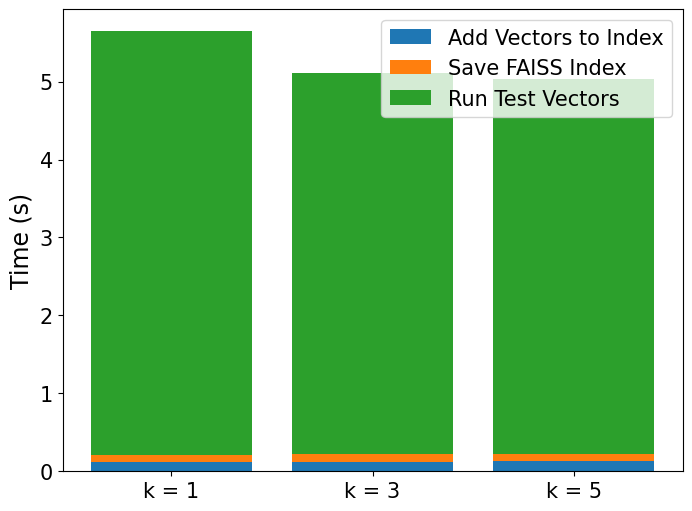

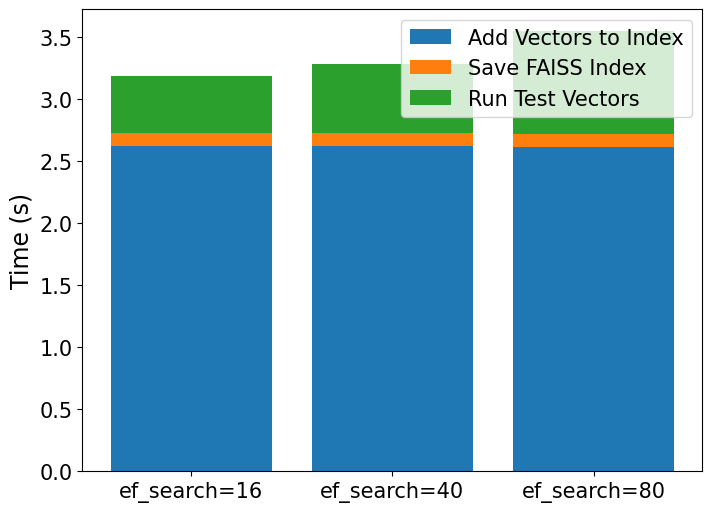

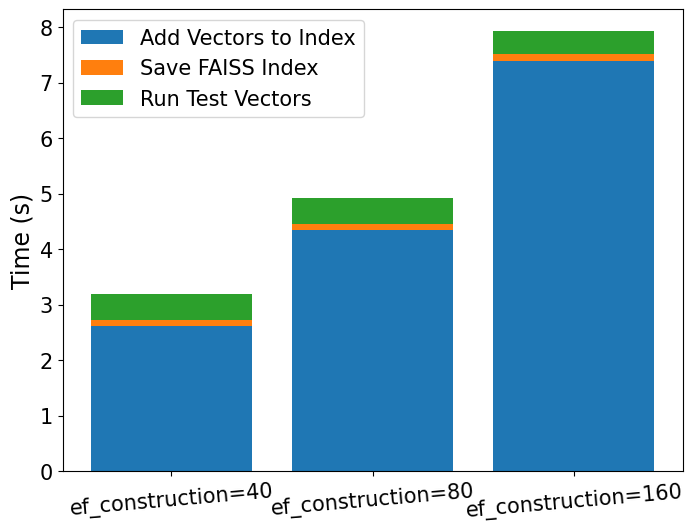

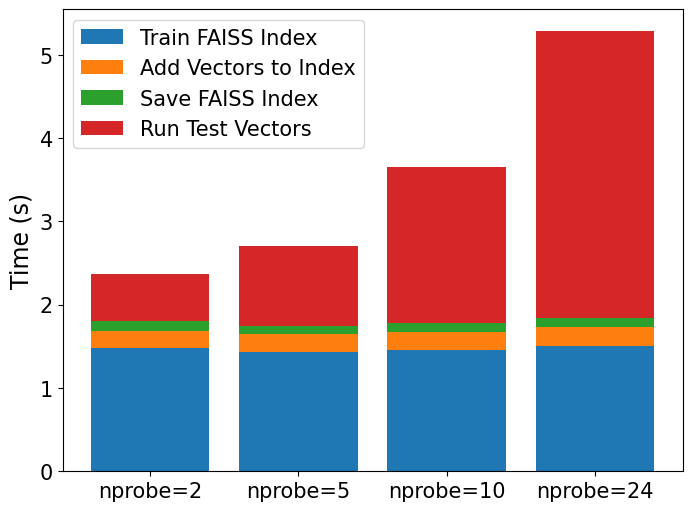

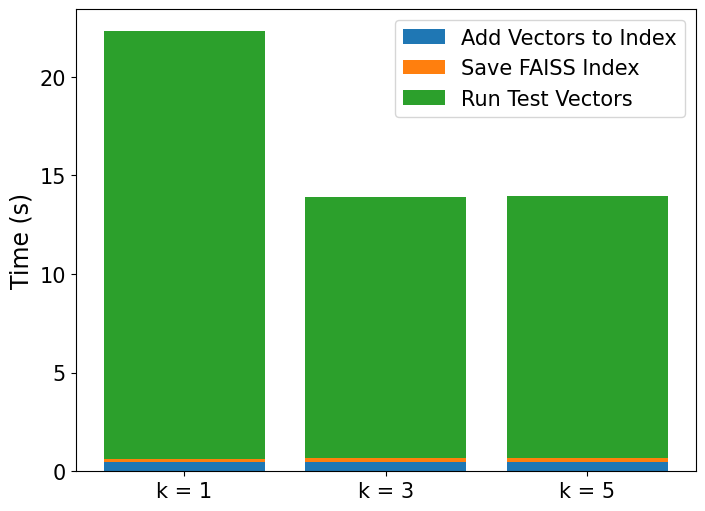

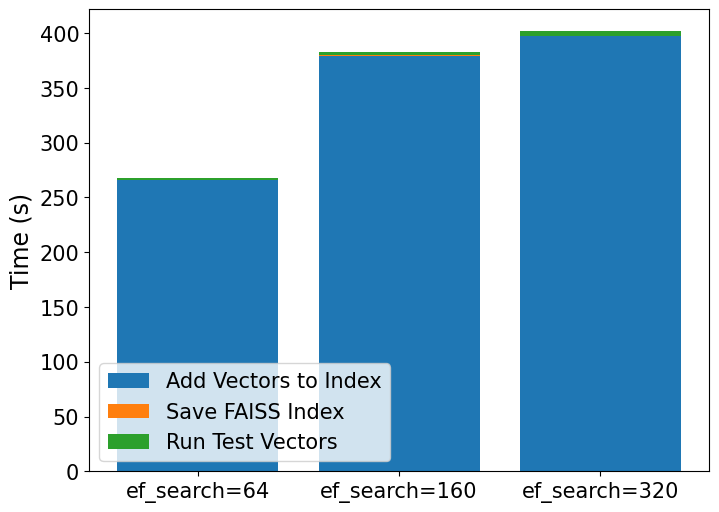

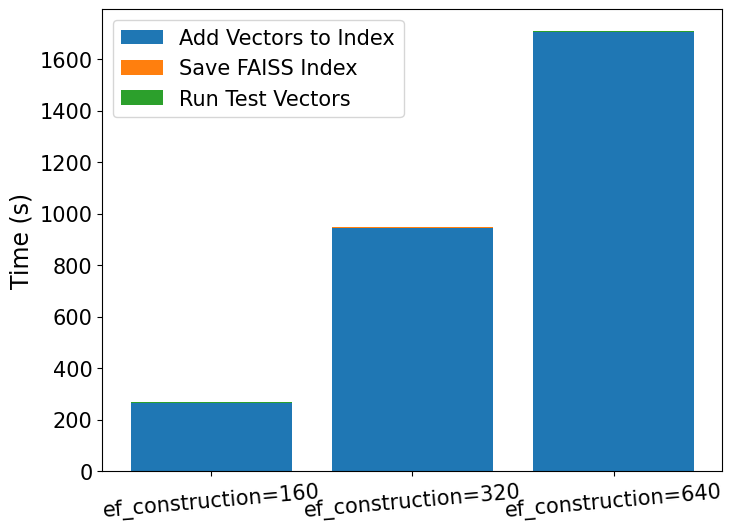

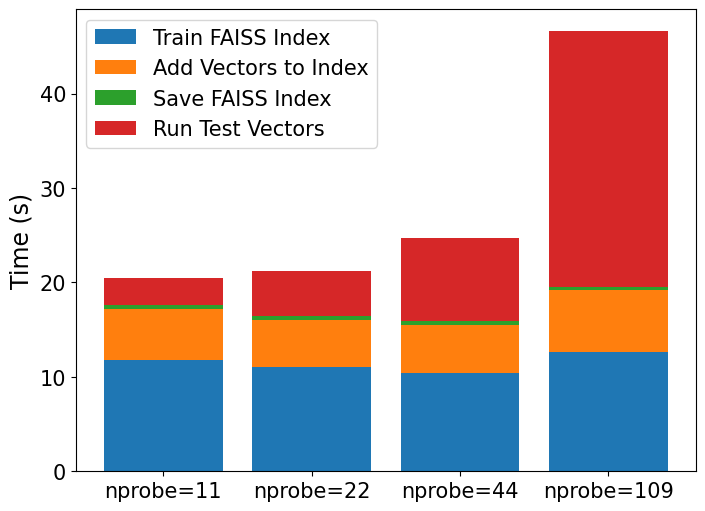

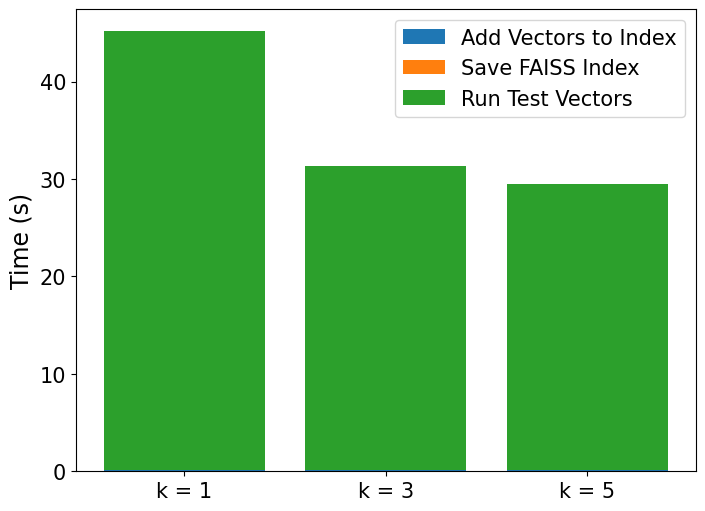

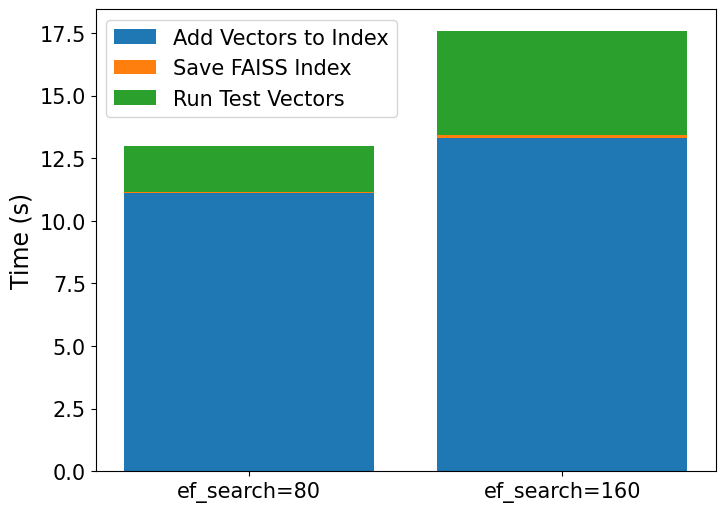

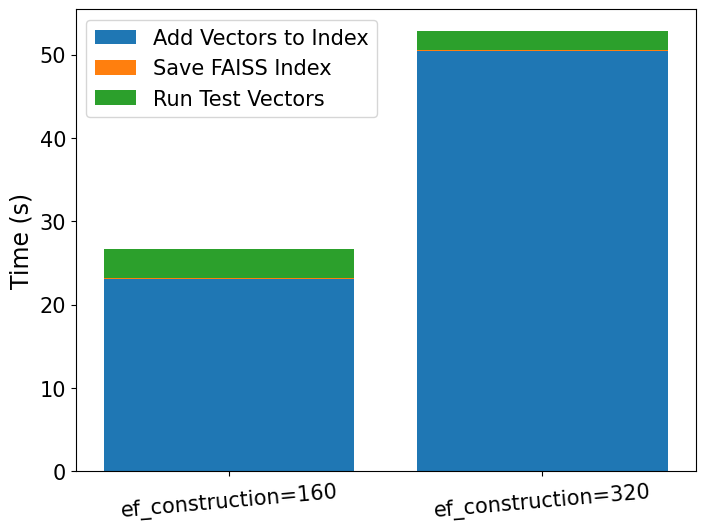

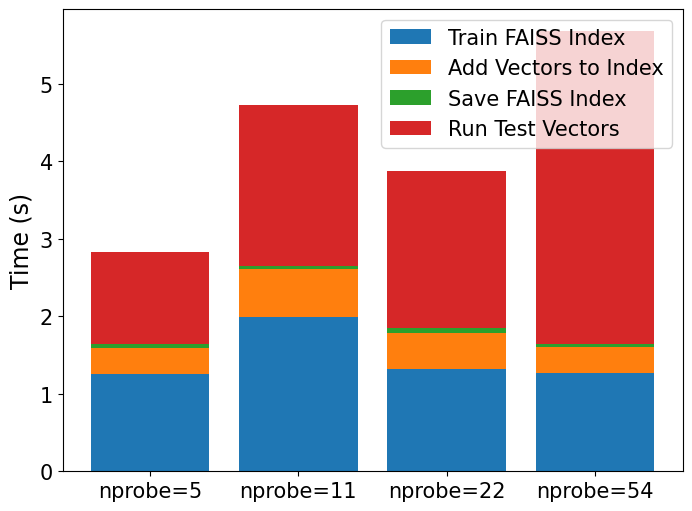

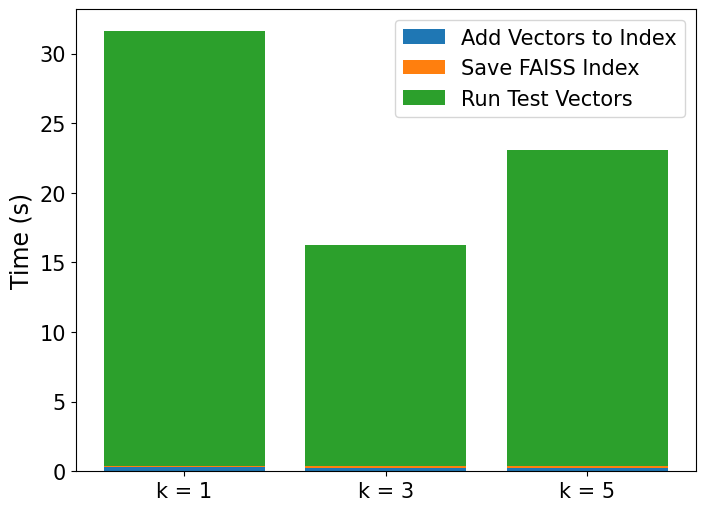

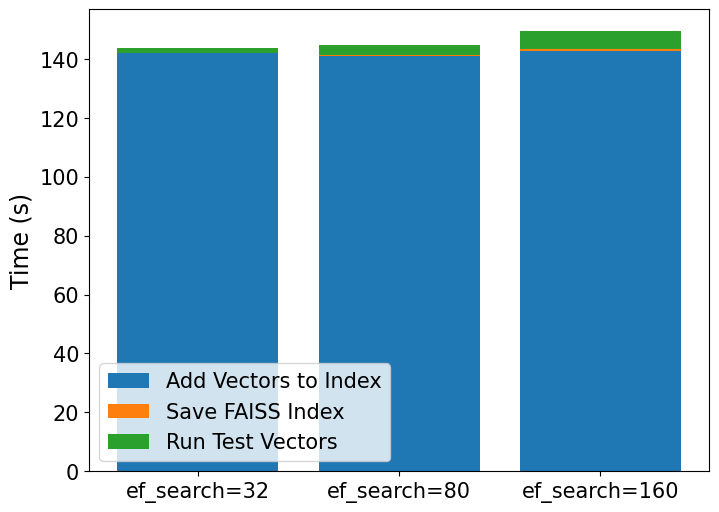

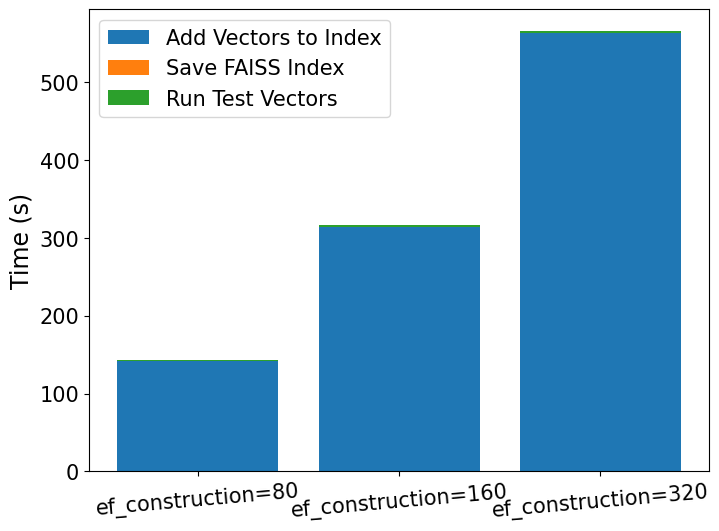

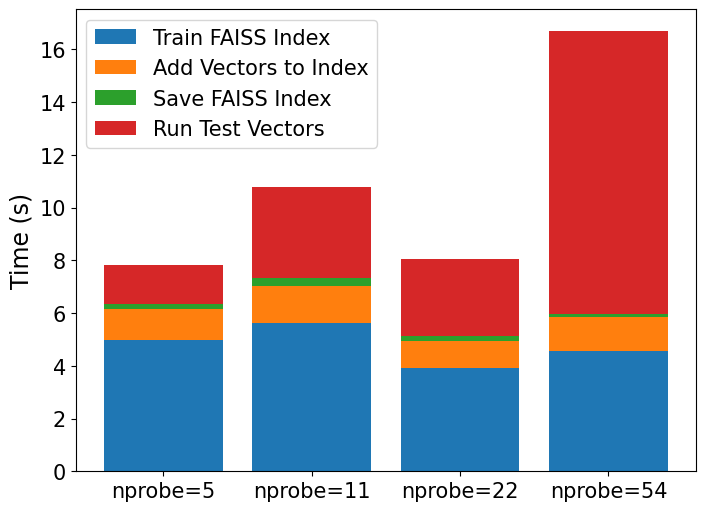

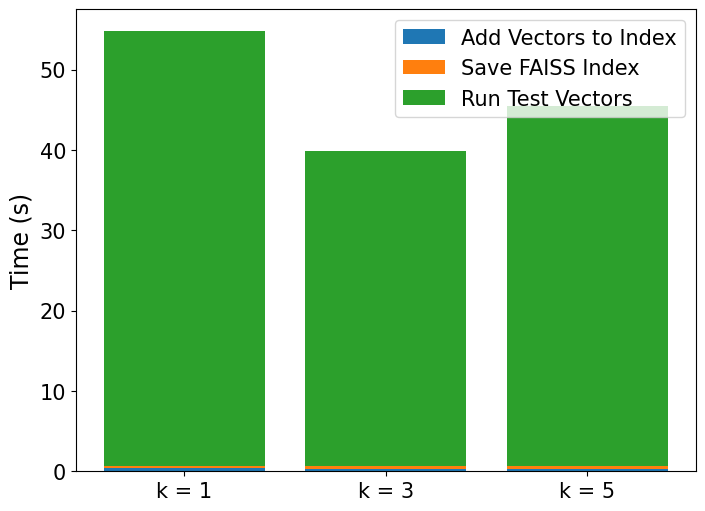

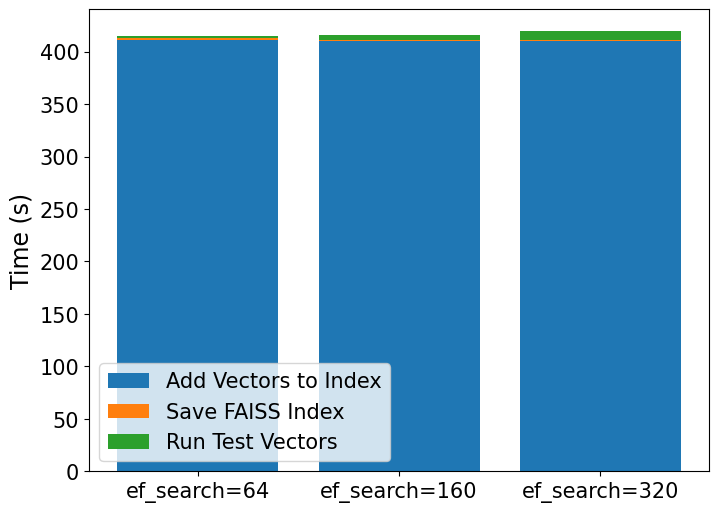

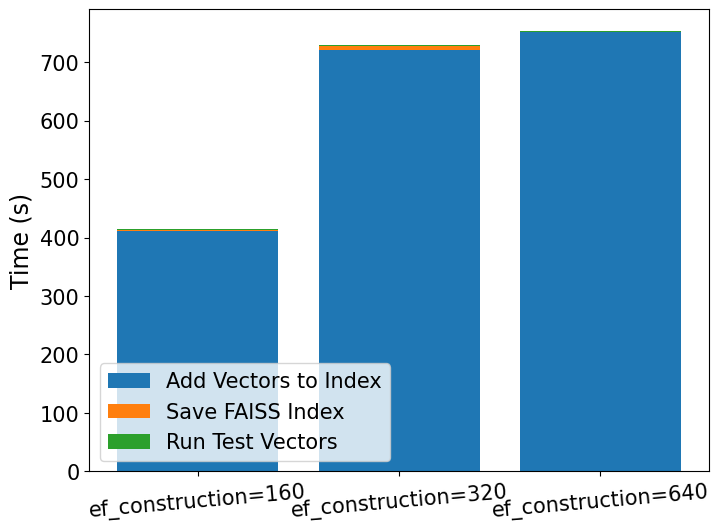

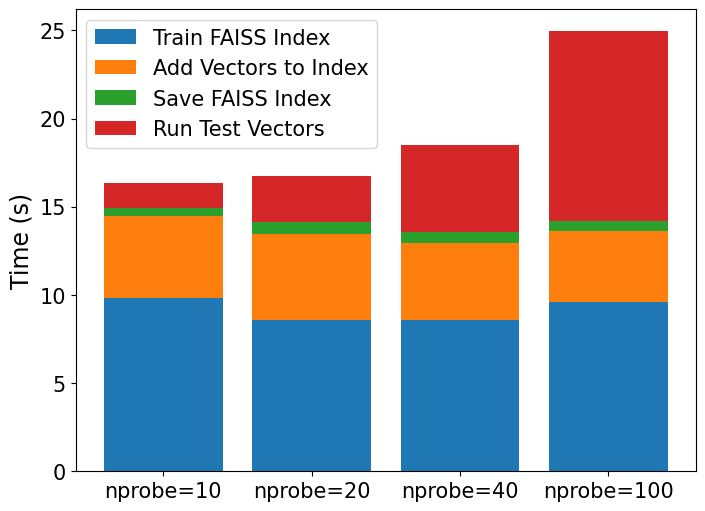

In [15]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import ast
from matplotlib.ticker import FuncFormatter

RESULTS_DIR = "./ann/results"
OUTPUT_DIR = "./figures/ann"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# -----------------------------
# Parsing helpers
# -----------------------------
def parse_config(name):
    
    with open(os.path.join(RESULTS_DIR, name, "config.json")) as f:
        config = json.load(f)

    params = {
        "dataset": config["ann_dataset"]["name"],
        "index_type": config["faiss"]["method"],
        "k": config["faiss"]["top_k"],
        "metric": config["faiss"]["metric"],
        "m": None,
        "ef_construction": None,
        "ef_search": None,
        "nlist": None,
        "nprobe": None,
        "num_training_vectors": None
    }
    
    if "m" in config["faiss"]["config"]:
        params["m"] = config["faiss"]["config"]["m"]

    if "ef_construction" in config["faiss"]["config"]:
        params["ef_construction"] = config["faiss"]["config"]["ef_construction"]

    if "ef_search" in config["faiss"]["config"]:
        params["ef_search"] = config["faiss"]["config"]["ef_search"]

    if "nlist" in config["faiss"]["config"]:
        params["nlist"] = config["faiss"]["config"]["nlist"]

    if "nprobe" in config["faiss"]["config"]:
        params["nprobe"] = config["faiss"]["config"]["nprobe"]
        
    if "num_training_vectors" in config["faiss"]["config"]:
        params["num_training_vectors"] = config["faiss"]["config"]["num_training_vectors"]

    return params

# Convert recall column to actual lists
def parse_recall(val):
    if isinstance(val, str):
        return ast.literal_eval(val)
    return val


# -----------------------------
# Load all results
# -----------------------------
def load_results():
    rows = []

    for folder in os.listdir(RESULTS_DIR):
        cfg = parse_config(folder)

        file = os.path.join(RESULTS_DIR, folder, "metrics.json")
        with open(file) as f:
            data = json.load(f)
        

        metrics = data["dataset"]["metrics"]
        hardware = data["hardware"]
        overall = data["overall"]
        faiss_metrics = data["dataset"]["faiss_metrics"]

        recall = list(metrics["recall@k"].values())
        precision = list(metrics["precision@k"].values())
        latency = metrics["latency"]["mean_ns"] / 1e3  # convert to us
        qps = metrics["qps"]

        memory = hardware["memory"]
        peak_memory = memory["peakMB"] - memory["beforeMB"]
        
        total_time_sec = overall["benchmarkTimeMs"] / 1000
        test_time_sec = overall["testTimeMs"] / 1000

        row = {
            **cfg,
            "recall": recall,
            "precision": precision,
            "mean_latency_us": latency,
            "qps": qps,
            "memory_mb": peak_memory,
            "total_time_sec": total_time_sec,   
            "init_index_time_sec": faiss_metrics["initIndexTimeNs"] / 1e9,
            "load_time_sec": faiss_metrics["loadTimeNs"] / 1e9,
            "save_time_sec": faiss_metrics["saveTimeNs"] / 1e9,
            "training_time_sec": faiss_metrics["trainingTimeNs"] / 1e9,
            "build_time_sec": faiss_metrics["buildTimeMs"] / 1000,
            "add_time_sec": faiss_metrics["addTimeNs"]["totalNs"] / 1e9,
            "read_time_sec": faiss_metrics["readTimeNs"]["totalNs"] / 1e9,
            "test_time_sec": test_time_sec
        }

        rows.append(row)

    df = pd.DataFrame(rows)
    return df


# -----------------------------
# Plotting functions
# -----------------------------

def plot_k_vs_recall(df, index_type):
    # Filter: index_type = index_type and k = 5
    # For HNSW & IVF, I have noticed that all configurations follow the same pattern.
    # Therefore, I will choose only one config (first one) per dataset.
    filtered_df = df[(df["index_type"] == index_type) & (df["k"] == 5)].groupby("dataset").first().reset_index()
    
    # filter ny_times for all types for now
    filtered_df = filtered_df[filtered_df["dataset"] != "ny_times"]

    plt.figure(figsize=(7, 5))

    for _, row in filtered_df.iterrows():
        dataset = row["dataset"]
        if index_type == "hnsw":
            m = int(row["m"])
            ef_search = int(row["ef_search"])
            ef_construction = int(row["ef_construction"])
            label = f"{dataset}" #  | m={m} | ef_search={ef_search} | ef_construction={ef_construction}
        elif index_type == "ivf":
            nprobe = int(row["nprobe"])
            nlist = int(row["nlist"])
            num_training_vectors = int(row["num_training_vectors"])
            label = f"{dataset}" #  | nprobe={nprobe} | nlist={nlist} | num training vectors={num_training_vectors}"
        else:
            label = dataset
        
        # Convert recall column to list if it's stored as a string
        recall_values = row["recall"]
        if isinstance(recall_values, str):
            recall_values = ast.literal_eval(recall_values)
        
        ks = list(range(1, len(recall_values) + 1))
        
        plt.plot(ks, recall_values, marker="o", label=label)

    plt.xlabel("K", fontsize=17)
    plt.ylabel("Recall", fontsize=17)
    # plt.title(f"Recall@k for {index_type} index")
    plt.legend(title="Dataset")
    plt.grid(True)
    plt.yticks(fontsize=13)
    plt.xticks(ticks=[1, 2, 3, 4, 5], fontsize=13)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"k_vs_recall_{index_type}.pdf"), format="pdf", dpi=200)
    plt.show()

def plot_recall_vs_qps(df):
    df["recall_list"] = df["recall"].apply(parse_recall)

    # Extract recall@5
    df["recall_at_5"] = df["recall_list"].apply(lambda x: x[4] if len(x) >= 5 else None)

    # Remove rows where recall@5 is missing
    
    chosen_nlist = {
        "fashion_mnist": 1960,
        "glove_100": 1088,
        "last_fm": 2163,
        "ny_times": 2154,
        "sift": 1000
    }
    
    df = df.dropna(subset=["recall_at_5", "qps", "index_type"])

    for dataset, dataset_df in df.groupby("dataset"):
        plt.figure()
        # Group by index_type
        for index_type, group in dataset_df.groupby("index_type"):
            if index_type == "flat":
                continue            
            group = group.sort_values("recall_at_5")

            if index_type == "ivf":
                subset = group[(group["k"] == 5) & (group["nlist"] == chosen_nlist[dataset])]
            else:
                subset = group[(group["k"] == 5) & (group["ef_construction"] == 160)]

            plt.plot(
                subset["recall_at_5"],
                subset["qps"],
                marker="o",
                label=index_type
            )

        plt.xlabel("Recall@5", fontsize=17)
        plt.ylabel("QPS", fontsize=17)
        plt.xticks(fontsize=13)
        plt.yticks(fontsize=13)

        # Format y ticks as 3K, 30K, etc.
        formatter = FuncFormatter(lambda x, _: f"{int(x/1000)}K" if abs(x) >= 1000 else str(int(x)))
        plt.gca().yaxis.set_major_formatter(formatter)

        # plt.title(f"Recall@5 vs QPS by index type for {dataset}")
        plt.grid(True)
        # Legend above plot
        plt.legend(title="Index Type")
        plt.savefig(os.path.join(OUTPUT_DIR, f"recall_vs_qps_{dataset}.pdf"), format="pdf", dpi=200)
        plt.show()

def plot_memory(df):
    # Compute mean and variance per dataset + index_type
    stats = (
        df
        .groupby(["dataset", "index_type"])["memory_mb"]
        .agg(["mean", "var"])
        .reset_index()
    )
    
    # Remove ny_times for all types for now
    stats = stats[stats["dataset"] != "ny_times"]

    plt.figure(figsize=(7, 5))

    # Plot one line per dataset
    for dataset, dataset_df in stats.groupby("dataset"):
        plt.errorbar(
            dataset_df["index_type"],
            dataset_df["mean"],
            yerr=dataset_df["var"]**0.5,
            marker="o",
            capsize=4,
            label=dataset
        )


    plt.xlabel("Index Type", fontsize=17)
    plt.ylabel("Peak Memory (MB)", fontsize=17)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    # plt.title("Peak Memory by Index Type")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.legend(title="Dataset")
    plt.savefig(os.path.join(OUTPUT_DIR, f"memory_usage.pdf"), format="pdf", dpi=200)
    plt.show()

def plot_time_breakdowns(df):
    for dataset, dataset_df in df.groupby("dataset"):

        def plot_group(group_df, title_suffix):
            labels = []
            for _, row in group_df.iterrows():
                index_type = row["index_type"]
                if index_type == "hnsw":
                    ef_search = int(row["ef_search"])
                    ef_construction = int(row["ef_construction"])
                    if "ef_search" in title_suffix:
                        label = f"ef_construction={ef_construction}"
                    else:
                        label = f"ef_search={ef_search}"
                elif index_type == "ivf":
                    nprobe = int(row["nprobe"])
                    label = f"nprobe={nprobe}"
                else:
                    k = int(row["k"])
                    label = f"k = {k}"
                    
                labels.append(label)
            
            init_list = group_df["init_index_time_sec"].tolist()
            training_list = group_df["training_time_sec"].tolist()
            read_list = group_df["read_time_sec"].tolist()
            add_list = group_df["add_time_sec"].tolist()
            save_load_list = group_df["save_time_sec"].tolist()
            test_list = group_df["test_time_sec"].tolist()

            plt.figure(figsize=(8, 6))
            bottom = [0] * len(labels)

            lists = [add_list, save_load_list, test_list]
            legend_labels = [
                    "Add Vectors to Index",
                    "Save FAISS Index",
                    "Run Test Vectors",
                ]
            
            if "ivf" in title_suffix:
                lists.insert(0, training_list)
                legend_labels.insert(0, "Train FAISS Index")
                
            for values, name in zip(lists, legend_labels):
                plt.bar(labels, values, bottom=bottom, label=name)
                bottom = [b + v for b, v in zip(bottom, values)]

            plt.ylabel("Time (s)", fontsize=17)
            # plt.title(f"{dataset} - {title_suffix}")
            plt.legend(fontsize=15)
            if "ef_search" in title_suffix:
                plt.xticks(rotation=5, fontsize=15)
            else:
                plt.xticks(fontsize=15)
            plt.yticks(fontsize=15)
            if dataset == "fashion_mnist":
                plt.savefig(os.path.join(OUTPUT_DIR, f"breakdown_{title_suffix}_{dataset}.pdf"), format="pdf", dpi=200)
            plt.show()

        # =========================
        # 1. FLAT
        # =========================
        flat_df = dataset_df[dataset_df["index_type"] == "flat"]
        flat_df = flat_df.sort_values("k")
        
        if not flat_df.empty:
            plot_group(flat_df, "flat")

        # =========================
        # 2. HNSW
        # =========================
        hnsw_df = dataset_df[(dataset_df["index_type"] == "hnsw") & (dataset_df["k"] == 5)]

        if not hnsw_df.empty:
            # Group by ef_construction
            for efc, group in hnsw_df.groupby("ef_construction"):
                group = group.sort_values("ef_search")
                plot_group(group, f"hnsw_ef_construction")
                break  # only first combination

            # Group by ef_search
            for efs, group in hnsw_df.groupby("ef_search"):
                group = group.sort_values("ef_construction")
                plot_group(group, f"hnsw_ef_search")
                break  # only first combination

        # =========================
        # 3. IVF
        # =========================
        ivf_df = dataset_df[(dataset_df["index_type"] == "ivf") & (dataset_df["k"] == 5)]
        ivf_df = ivf_df.sort_values("nprobe")

        if not ivf_df.empty:
            for nlist, group in ivf_df.groupby("nlist"):
                plot_group(group, f"ivf")
                break  # only first combination

def plot_latency_vs_recall(df):
    
    # Ensure recall@1 exists
    if "recall_at_1" not in df.columns:
        df["recall_list"] = df["recall"].apply(parse_recall)
        df["recall_at_1"] = df["recall_list"].apply(lambda x: x[0])

    df = df.dropna(subset=["mean_latency_us", "recall_at_1"])

    for dataset, dataset_df in df.groupby("dataset"):
        plt.figure(figsize=(8, 5))

        # -------------------------
        # 1. FLAT
        # -------------------------
        flat_df = dataset_df[dataset_df["index_type"] == "flat"]
        if not flat_df.empty:
            flat_df = flat_df.sort_values("k")
            # Pick only k=1 for flat since it's the only one that makes sense
            flat_df = flat_df[flat_df["k"] == 1]
            plt.plot(
                flat_df["recall_at_1"],
                flat_df["mean_latency_us"],
                marker="o",
                label="flat"
            )

            # annotate points with k
            for _, row in flat_df.iterrows():
                plt.text(
                    row["recall_at_1"] - 0.005,
                    row["mean_latency_us"],
                    f"k={row['k']}",
                    fontsize=9,
                    ha="center"
                )

        # -------------------------
        # 2. HNSW
        # -------------------------
        hnsw_df = dataset_df[
            (dataset_df["index_type"] == "hnsw") & (dataset_df["k"] == 1)
        ]

        if not hnsw_df.empty:
            # by ef_construction (label ef_search)
            for efc, group in hnsw_df.groupby("ef_construction"):
                group = group.sort_values("ef_search")
                plt.plot(
                    group["recall_at_1"],
                    group["mean_latency_us"],
                    marker="o",
                    label=f"hnsw (ef_construction={int(efc)})"
                )

                for _, row in group.iterrows():
                    plt.text(
                        row["recall_at_1"],
                        row["mean_latency_us"] + 10,
                        f"efs={int(row['ef_search'])}",
                        fontsize=9,
                        ha="center"
                    )
                break

            # # by ef_search (label ef_construction)
            # for efs, group in hnsw_df.groupby("ef_search"):
            #     group = group.sort_values("ef_construction")
            #     plt.plot(
            #         group["recall_at_1"],
            #         group["mean_latency_us"],
            #         marker="o",
            #         linestyle="--",
            #         label=f"hnsw (ef_search={efs})"
            #     )

            #     for _, row in group.iterrows():
            #         plt.text(
            #             row["recall_at_1"],
            #             row["mean_latency_us"] - 20,
            #             f"efc={row['ef_construction']}",
            #             fontsize=9,
            #             ha="center"
            #         )
            #     break

        # -------------------------
        # 3. IVF
        # -------------------------
        ivf_df = dataset_df[
            (dataset_df["index_type"] == "ivf") & (dataset_df["k"] == 1)
        ]

        if not ivf_df.empty:
            for nlist, group in ivf_df.groupby("nlist"):
                group = group.sort_values("nprobe")
                plt.plot(
                    group["recall_at_1"],
                    group["mean_latency_us"],
                    marker="o",
                    label=f"ivf (nlist={int(nlist)})"
                )

                for _, row in group.iterrows():
                    plt.text(
                        row["recall_at_1"],
                        row["mean_latency_us"] + 20,
                        f"np={int(row['nprobe'])}",
                        fontsize=9,
                        ha="center"
                    )
                break

        plt.xlabel("Recall@1", fontsize=17)
        plt.ylabel("Mean Retrieval Latency (ms)", fontsize=17)
        plt.xticks(fontsize=13)
        plt.yticks(fontsize=13)
        # plt.title(f"Mean Retrieval Latency (per query) vs Recall@1 ({dataset})")
        plt.grid(True)
        plt.legend(fontsize=13)
        plt.savefig(os.path.join(OUTPUT_DIR, f"latency_vs_recall_{dataset}.pdf"), format="pdf", dpi=200)
        plt.show()

# -----------------------------
# Main
# -----------------------------
df = load_results()
df.to_csv(os.path.join(OUTPUT_DIR, "aggregated_results.csv"), index=False)
df.to_excel(os.path.join(OUTPUT_DIR, "aggregated_results.xlsx"), index=False)

# for index_type in df["index_type"].unique():
#     plot_k_vs_recall(df, index_type)

# plot_recall_vs_qps(df)

# plot_memory(df)

# plot_latency_vs_recall(df)

plot_time_breakdowns(df)

# Task Results

********** trivia_qa ********** 


Total Output Tokens Statistics
Runs: 27
Mean: 28942.33
Standard Deviation: 2251.25


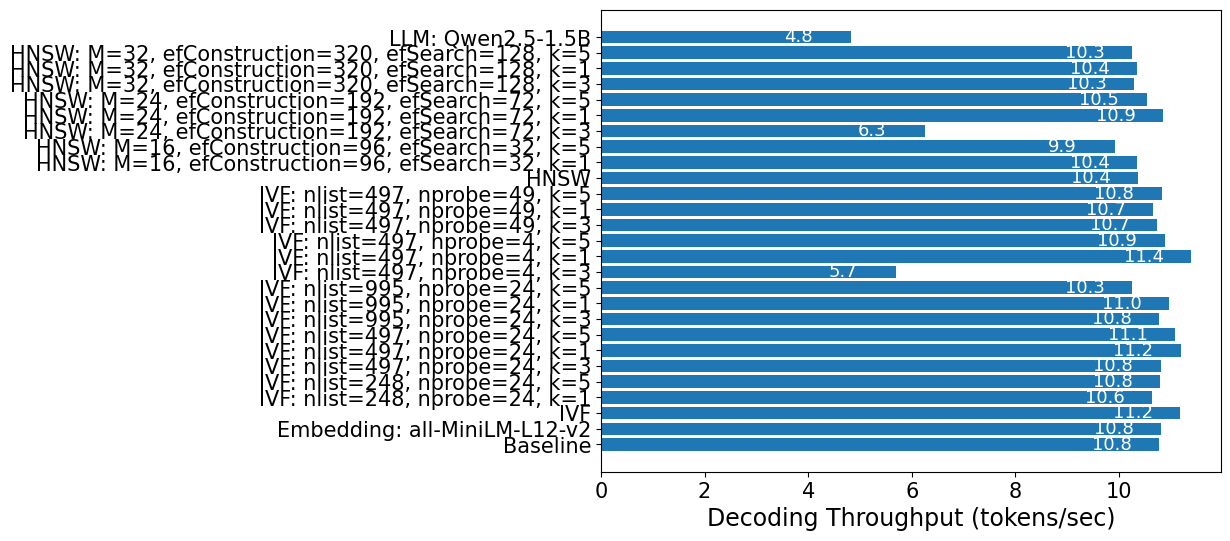

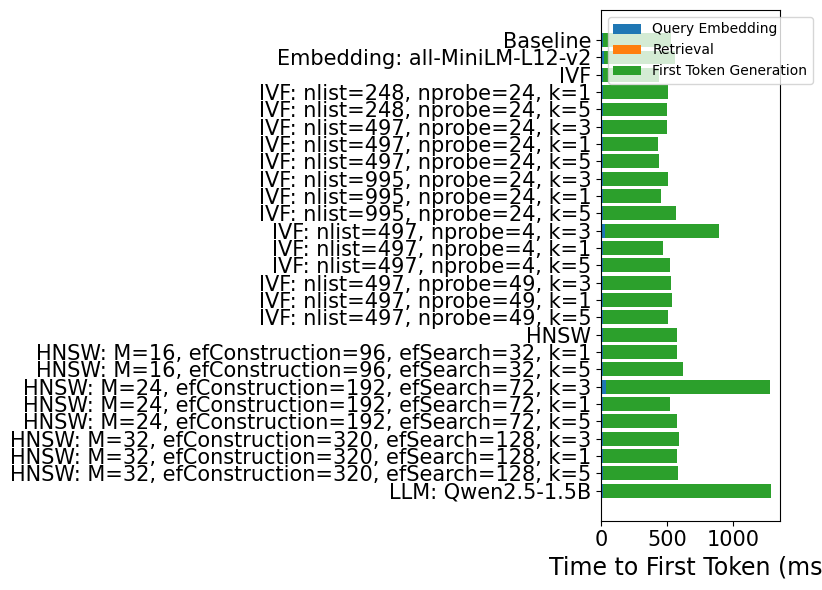

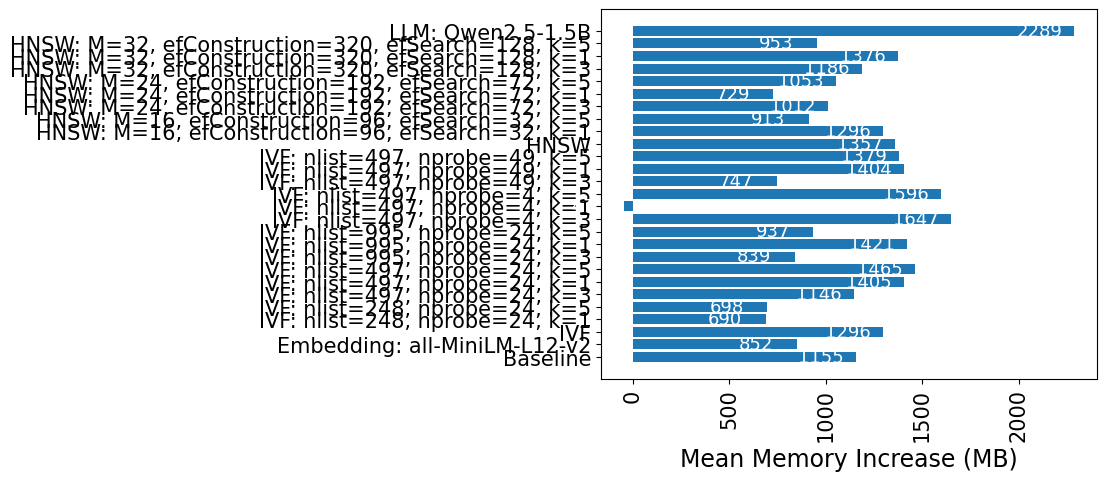

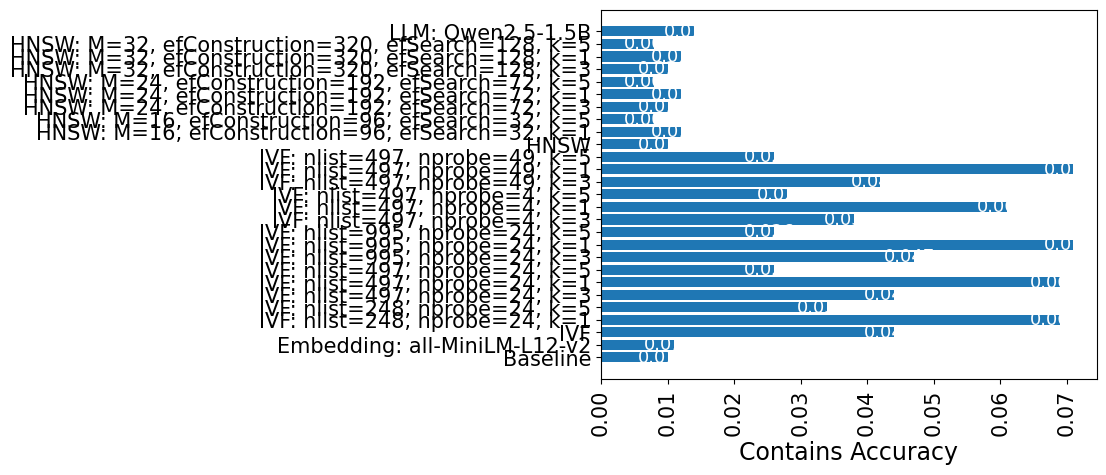

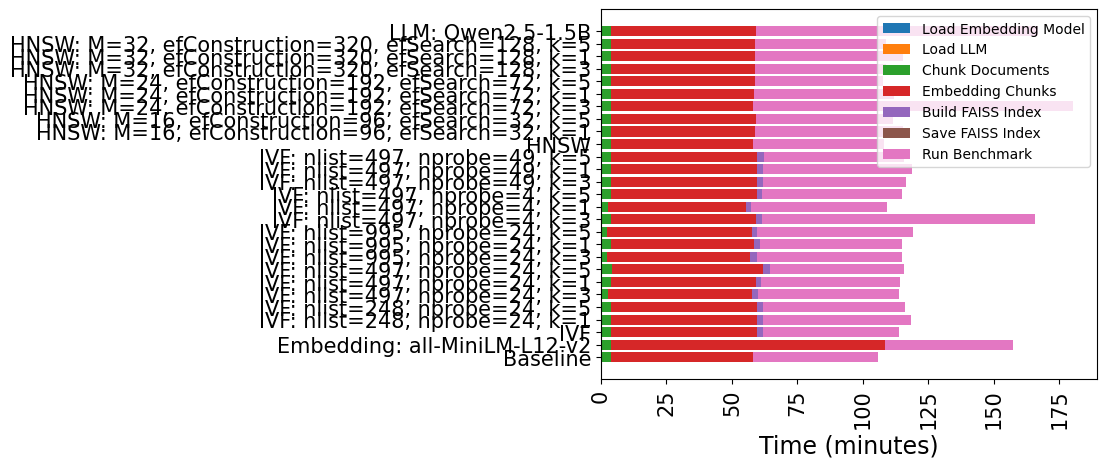

In [5]:
import os
import json
import matplotlib.pyplot as plt
import ast
import statistics

RESULTS_DIR = "./results"
OUTPUT_DIR = "./figures/task"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# Convert recall column to actual lists
def parse_recall(val):
    if isinstance(val, str):
        return ast.literal_eval(val)
    return val


# -----------------------------
# Load all results
# -----------------------------
def load_results(dataset, i):

    with open(os.path.join(RESULTS_DIR, f"{dataset}_{i}", "config.json")) as f:
        config = json.load(f)
        
    with open(os.path.join(RESULTS_DIR, f"{dataset}_{i}", "metrics.json")) as f:
        metrics = json.load(f)
    
    # result = {
    #     "config": config,
    #     "metrics": metrics
    # }

    return metrics

def plot_breakdown(json_runs, labels=None):
    if labels is None:
        labels = [f"Run {i+1}" for i in range(len(json_runs))]

    # Containers
    embedding_init = []
    llm_init = []
    overall_duration = []
    save_time = []
    chunking = []
    embedding = []
    add_time = []

    for item in json_runs:
        # Convert ms → minutes
        embedding_init.append(item["overall"]["embeddingInitTimeMs"] / 60000)
        llm_init.append(item["overall"]["llmInitTimeMs"] / 60000)
        overall_duration.append(
            item["task"]["generation_metrics"]["overall_duration_ms"] / 60000
        )

        # Convert ns → ms → minutes
        save_time.append(item["task"]["faiss_metrics"]["saveTimeNs"] / 1e6 / 60000)
        chunking.append(item["task"]["faiss_metrics"]["chunkingTimeNs"]["totalNs"] / 1e6 / 60000)
        embedding.append(item["task"]["faiss_metrics"]["embeddingTimeNs"]["totalNs"] / 1e6 / 60000)
        add_time.append(item["task"]["faiss_metrics"]["addTimeNs"]["totalNs"] / 1e6 / 60000)

    # Plot
    plt.figure()
    left = [0] * len(labels)

    def stack(values, label):
        nonlocal left
        plt.barh(labels, values, left=left, label=label)
        left = [b + v for b, v in zip(left, values)]

    stack(embedding_init, "Load Embedding Model")
    stack(llm_init, "Load LLM")
    stack(chunking, "Chunk Documents")
    stack(embedding, "Embedding Chunks")
    stack(add_time, "Build FAISS Index")
    stack(save_time, "Save FAISS Index")
    stack(overall_duration, "Run Benchmark")

    plt.xlabel("Time (minutes)", fontsize=17)
    plt.legend()
    plt.xticks(fontsize=15, rotation=90)
    plt.yticks(fontsize=15)
    plt.savefig(os.path.join(OUTPUT_DIR, f"breakdown_triviaqa.pdf"), bbox_inches="tight", format="pdf", dpi=200)
    plt.show()


def plot_contains_accuracy(json_runs, labels=None):
    if labels is None:
        labels = [f"Run {i+1}" for i in range(len(json_runs))]

    contains_vals = []

    for item in json_runs:
        contains = item["task"]["generation_metrics"]["accuracy"]["contains"]
        contains_vals.append(contains)

    plt.figure()
    bars = plt.barh(labels, contains_vals)
    
    # --- annotate values ---
    for bar in bars:
        width = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2

        plt.text(
            width - 0.0045,            # x position
            y,                # y position
            f"{width:.3f}",   # text
            va="center",
            ha="left",
            fontsize=13,
            color="white"
        )

    plt.xlabel("Contains Accuracy", fontsize=17)
    plt.xticks(fontsize=15, rotation=90)
    plt.yticks(fontsize=15)
    plt.savefig(os.path.join(OUTPUT_DIR, f"accuracy_triviaqa.pdf"), bbox_inches="tight", format="pdf", dpi=200)
    plt.show()
    
def plot_throughput(json_runs, labels=None):
    if labels is None:
        labels = [f"Run {i+1}" for i in range(len(json_runs))]

    throughput_vals = []

    for item in json_runs:
        tps = item["task"]["generation_metrics"]["decoding_speed_toks_per_sec"]["avg"]
        throughput_vals.append(tps)

    plt.figure(figsize=(8, 6))

    bars = plt.barh(labels, throughput_vals)

    plt.xlabel("Decoding Throughput (tokens/sec)", fontsize=17)
    plt.yticks(fontsize=15)
    plt.xticks(fontsize=15)
    
    # --- annotate values ---
    for bar in bars:
        width = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2

        plt.text(
            width - 1.3,            # x position
            y,                # y position
            f"{width:.1f}",   # text
            va="center",
            ha="left",
            fontsize=13,
            color="white"
        )

    plt.savefig(
        os.path.join(OUTPUT_DIR, "throughput_triviaqa.pdf"),
        format="pdf",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    
def plot_ttft_breakdown(json_runs, labels=None):
    if labels is None:
        labels = [f"Run {i+1}" for i in range(len(json_runs))]

    query_times = []
    retrieve_times = []
    generation_times = []

    for item in json_runs:
        metrics = item["task"]["generation_metrics"]

        query_ms = metrics["query_embeddings_ms"]["avg"]
        retrieve_ms = metrics["retrieve_top_k_docs_ns"]["avg"] / 1e6
        ttft_ms = metrics["ttft_ms"]["avg"]

        generation_ms = ttft_ms - query_ms - retrieve_ms
        generation_ms = max(generation_ms, 0)

        query_times.append(query_ms)
        retrieve_times.append(retrieve_ms)
        generation_times.append(generation_ms)

    # ---- Plot ----
    plt.figure(figsize=(8, 6))

    left = [0] * len(labels)

    def stack(values, label):
        nonlocal left
        plt.barh(labels, values, left=left, label=label)
        left = [l + v for l, v in zip(left, values)]

    stack(query_times, "Query Embedding")
    stack(retrieve_times, "Retrieval")
    stack(generation_times, "First Token Generation")

    plt.xlabel("Time to First Token (ms)", fontsize=17)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

    plt.legend()
    plt.gca().invert_yaxis()   # optional: first run at top
    plt.tight_layout()

    plt.savefig(
        os.path.join(OUTPUT_DIR, "ttft_breakdown_triviaqa.pdf"),
        bbox_inches="tight",
        format="pdf",
        dpi=200,
    )

    plt.show()

def plot_mean_memory(json_runs, labels=None):
    if labels is None:
        labels = [f"Run {i+1}" for i in range(len(json_runs))]

    mean_deltas = []

    for item in json_runs:
        before = item["hardware"]["memory"]["beforeMB"]
        mean = item["hardware"]["memory"]["meanMB"]
        delta = mean - before
        mean_deltas.append(delta)

    plt.figure()
    bars = plt.barh(labels, mean_deltas)
    
    # --- annotate values ---
    for bar in bars:
        width = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2

        plt.text(
            width - 300,            # x position
            y,                # y position
            f"{width:.0f}",   # text
            va="center",
            ha="left",
            fontsize=13,
            color="white"
        )

    plt.xlabel("Mean Memory Increase (MB)", fontsize=17)
    plt.xticks(fontsize=15, rotation=90)
    plt.yticks(fontsize=15)
    plt.savefig(os.path.join(OUTPUT_DIR, f"mean_memory_triviaqa.pdf"), bbox_inches="tight", format="pdf", dpi=200)
    plt.show()

def calc_output_token_stats(json_runs):
    output_tokens = []

    for item in json_runs:
        tokens = item["task"]["generation_metrics"]["total_output_tokens"]
        output_tokens.append(tokens)

    mean_val = statistics.mean(output_tokens)

    if len(output_tokens) > 1:
        std = statistics.stdev(output_tokens)
    else:
        std = 0.0

    print("Total Output Tokens Statistics")
    print(f"Runs: {len(output_tokens)}")
    print(f"Mean: {mean_val:.2f}")
    print(f"Standard Deviation: {std:.2f}")


# -----------------------------
# Main
# -----------------------------
for dataset in ["trivia_qa"]:
    print("*" * 10, dataset, "*" * 10, "\n\n")
    baseline = load_results(dataset, 0)
    embedding_all_minilm_l12_v2 = load_results(dataset, 1)
    # embedding_backend_xnnpack = load_results(dataset, 2)
    # embedding_backend_nnapi = load_results(dataset, 3)
    ivf__nlist_248__nprobe_24__k_3 = load_results(dataset, 4)
    ivf__nlist_248__nprobe_24__k_1 = load_results(dataset, 5)
    ivf__nlist_248__nprobe_24__k_5 = load_results(dataset, 6)
    ivf__nlist_497__nprobe_24__k_3 = load_results(dataset, 7)
    ivf__nlist_497__nprobe_24__k_1 = load_results(dataset, 8)
    ivf__nlist_497__nprobe_24__k_5 = load_results(dataset, 9)
    ivf__nlist_995__nprobe_24__k_3 = load_results(dataset, 10)
    ivf__nlist_995__nprobe_24__k_1 = load_results(dataset, 11)
    ivf__nlist_995__nprobe_24__k_5 = load_results(dataset, 12)
    ivf__nlist_497__nprobe_4__k_3 = load_results(dataset, 13)
    ivf__nlist_497__nprobe_4__k_1 = load_results(dataset, 14)
    ivf__nlist_497__nprobe_4__k_5 = load_results(dataset, 15)
    ivf__nlist_497__nprobe_49__k_3 = load_results(dataset, 16)
    ivf__nlist_497__nprobe_49__k_1 = load_results(dataset, 17)
    ivf__nlist_497__nprobe_49__k_5 = load_results(dataset, 18)
    hnsw__m_16__ef_construction_96__ef_search_32__k_3 = load_results(dataset, 19)
    hnsw__m_16__ef_construction_96__ef_search_32__k_1 = load_results(dataset, 20)
    hnsw__m_16__ef_construction_96__ef_search_32__k_5 = load_results(dataset, 21)
    hnsw__m_24__ef_construction_192__ef_search_72__k_3 = load_results(dataset, 22)
    hnsw__m_24__ef_construction_192__ef_search_72__k_1 = load_results(dataset, 23)
    hnsw__m_24__ef_construction_192__ef_search_72__k_5 = load_results(dataset, 24)
    hnsw__m_32__ef_construction_320__ef_search_128__k_3 = load_results(dataset, 25)
    hnsw__m_32__ef_construction_320__ef_search_128__k_1 = load_results(dataset, 26)
    hnsw__m_32__ef_construction_320__ef_search_128__k_5 = load_results(dataset, 27)
    llm_qwen_1_5B = load_results(dataset, 28)
    # llm_dtype_q4 = load_results(dataset, 29)
    # llm_backend_xnnpack = load_results(dataset, 30)
    # llm_backend_nnapi = load_results(dataset, 31)


    results = [
        baseline,
        embedding_all_minilm_l12_v2,
        # embedding_backend_xnnpack,
        # embedding_backend_nnapi,
        ivf__nlist_248__nprobe_24__k_3,
        ivf__nlist_248__nprobe_24__k_1,
        ivf__nlist_248__nprobe_24__k_5,
        ivf__nlist_497__nprobe_24__k_3,
        ivf__nlist_497__nprobe_24__k_1,
        ivf__nlist_497__nprobe_24__k_5,
        ivf__nlist_995__nprobe_24__k_3,
        ivf__nlist_995__nprobe_24__k_1,
        ivf__nlist_995__nprobe_24__k_5,
        ivf__nlist_497__nprobe_4__k_3,
        ivf__nlist_497__nprobe_4__k_1,
        ivf__nlist_497__nprobe_4__k_5,
        ivf__nlist_497__nprobe_49__k_3,
        ivf__nlist_497__nprobe_49__k_1,
        ivf__nlist_497__nprobe_49__k_5,
        hnsw__m_16__ef_construction_96__ef_search_32__k_3,
        hnsw__m_16__ef_construction_96__ef_search_32__k_1,
        hnsw__m_16__ef_construction_96__ef_search_32__k_5,
        hnsw__m_24__ef_construction_192__ef_search_72__k_3,
        hnsw__m_24__ef_construction_192__ef_search_72__k_1,
        hnsw__m_24__ef_construction_192__ef_search_72__k_5,
        hnsw__m_32__ef_construction_320__ef_search_128__k_3,
        hnsw__m_32__ef_construction_320__ef_search_128__k_1,
        hnsw__m_32__ef_construction_320__ef_search_128__k_5,
        llm_qwen_1_5B,
        # llm_dtype_q4,
        # llm_backend_xnnpack,
        # llm_backend_nnapi
    ]
    
    labels = [
        "Baseline",
        "Embedding: all-MiniLM-L12-v2",
        # "Embedding: XNNPACK",
        # "Embedding: NNAPI",
        "IVF", # "IVF: nlist=248, nprobe=24, k=3",
        "IVF: nlist=248, nprobe=24, k=1",
        "IVF: nlist=248, nprobe=24, k=5",
        "IVF: nlist=497, nprobe=24, k=3",
        "IVF: nlist=497, nprobe=24, k=1",
        "IVF: nlist=497, nprobe=24, k=5",
        "IVF: nlist=995, nprobe=24, k=3",
        "IVF: nlist=995, nprobe=24, k=1",
        "IVF: nlist=995, nprobe=24, k=5",
        "IVF: nlist=497, nprobe=4, k=3",
        "IVF: nlist=497, nprobe=4, k=1",
        "IVF: nlist=497, nprobe=4, k=5",
        "IVF: nlist=497, nprobe=49, k=3",
        "IVF: nlist=497, nprobe=49, k=1",
        "IVF: nlist=497, nprobe=49, k=5",
        "HNSW", # "HNSW: M=16, efConstruction=96, efSearch=32, k=3",
        "HNSW: M=16, efConstruction=96, efSearch=32, k=1",
        "HNSW: M=16, efConstruction=96, efSearch=32, k=5",
        "HNSW: M=24, efConstruction=192, efSearch=72, k=3",
        "HNSW: M=24, efConstruction=192, efSearch=72, k=1",
        "HNSW: M=24, efConstruction=192, efSearch=72, k=5",
        "HNSW: M=32, efConstruction=320, efSearch=128, k=3",
        "HNSW: M=32, efConstruction=320, efSearch=128, k=1",
        "HNSW: M=32, efConstruction=320, efSearch=128, k=5",
        "LLM: Qwen2.5-1.5B",
        # "LLM: Dtype Q4",
        # "LLM: XNNPACK",
        # "LLM: NNAPI",
    ]

    calc_output_token_stats(results)
    
    # indecies = [0, 28, 29, 30, 32]
    # results_used = [results[i] for i in indecies]
    # labels_used = [labels[i] for i in indecies]
    
    plot_throughput(results, labels)
    
    # indecies = [0, 1, 2, 3, 4, 19, 28, 29, 30, 32]
    # results_used = [results[i] for i in indecies]
    # labels_used = [labels[i] for i in indecies]
    
    plot_ttft_breakdown(results, labels)
    
    plot_mean_memory(results, labels)
    
    # indecies2 = [0, 1, 2, 3, 4, 13, 19, 20, 28, 29, 30, 32]
    # results_used2 = [results[i] for i in indecies2]
    # labels_used2 = [labels[i] for i in indecies2]
    plot_contains_accuracy(results, labels)
    
    plot_breakdown(results, labels)